<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/SVD/RegionA_declineCurve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading Files

You can upload files from your local file system to the Colab environment using the `files.upload()` function from `google.colab`.

In [3]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving SampleWellDeclines.xlsx to SampleWellDeclines (1).xlsx
User uploaded file "SampleWellDeclines (1).xlsx" with length 20024 bytes


### Reviewing the Uploaded File

To inspect the contents of the uploaded Excel file, we can load it into a pandas DataFrame. Since `SampleWellDeclines.xlsx` is an Excel file, we'll use `pd.read_excel()`.

In [5]:
import pandas as pd

# Loading the newly uploaded Excel file
df = pd.read_excel('SampleWellDeclines (1).xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,WellID,M0,M1,M2,M3,M4,M5,M6,M7,M8,...,M27,M28,M29,M30,M31,M32,M33,M34,M35,M36
0,A1,155.0,898.0,1122.0,950,797,667.0,480,78,78,...,165.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A2,44.0,339.0,485.0,600,640,599.0,569,493,450,...,103.0,225.0,237.0,165.0,181.0,147.0,148.0,137.0,129.0,61.0
2,A3,129.0,346.0,461.0,422,380,356.0,295,209,254,...,174.0,198.0,173.0,131.0,152.0,135.0,138.0,130.0,135.0,117.0
3,A4,574.0,NaN,598.0,149,444,527.0,436,511,306,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A5,43.0,362.0,NaN,493,200,296.0,502,375,280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Creating a Representative Well Production Profile using Weighted SVD

To create a representative well production profile, we will follow these steps:
1.  **Identify Production Data**: Extract the columns representing monthly production (`M0` to `M36`).
2.  **Calculate 'Newness' Weights**: Assign a weight to each well. Wells with more `NaN` values (indicating shorter production history) will receive higher weights.
3.  **Handle Missing Values**: Fill `NaN` values in the production data with `0`, assuming that unrecorded months have zero production.
4.  **Scale the Data**: Standardize the production data to ensure that all months contribute equally to the SVD, regardless of their magnitude.
5.  **Apply Weights**: Multiply each row of the scaled production data by its assigned 'newness' weight.
6.  **Perform SVD**: Apply SVD to the weighted, scaled production matrix.
7.  **Extract Representative Profile**: The first principal component (first right singular vector) from the SVD will represent the dominant production decline pattern.
8.  **Rescale Profile**: Transform the extracted profile back to the original production units for interpretability and ensure all values are non-negative.

In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Identify production columns (M0 to M36)
production_cols = [f'M{i}' for i in range(37)]
production_df = df[production_cols]

# 2. Calculate 'Newness' weights
# A well is 'newer' if it has fewer recorded production months (more NaNs at the end).
# We want to give higher weights to wells with more NaNs.
nan_counts = production_df.isna().sum(axis=1)

# Simple weighting: more NaNs = higher weight. Add 1 to ensure minimum weight is 1.
weights = nan_counts + 1

# Normalize weights to avoid extreme values, while preserving relative differences
weights = weights / weights.sum() * len(df) # Scale to keep sum of weights approximately equal to number of wells.

# 3. Handle Missing Values: Fill NaNs with 0 for SVD
# This assumes unproduced months have 0 output.
production_filled = production_df.fillna(0)

# 4. Scale the data using StandardScaler
# Fit scaler on the *unweighted* data to get correct mean/std for inverse transform.
scaler = StandardScaler()
production_scaled = scaler.fit_transform(production_filled)

# 5. Apply row-wise weighting to the scaled data
# Convert weights Series to a NumPy array before reshaping
weighted_production_scaled = production_scaled * weights.to_numpy()[:, np.newaxis]

# 6. Perform SVD on the weighted and scaled data
U, s, Vt = np.linalg.svd(weighted_production_scaled, full_matrices=False)

# 7. Extract the first principal component as the representative profile
# The first row of Vt contains the components of the first principal component.
representative_profile_scaled = Vt[0, :]

# 8. Inverse transform to original scale and ensure non-negativity
# We use the mean and std dev from the original, unweighted data to inverse transform.
representative_profile = representative_profile_scaled * scaler.scale_ + scaler.mean_

# Production values cannot be negative, so clip any negative values to 0
representative_profile[representative_profile < 0] = 0

# Convert to a DataFrame for better display
representative_df = pd.DataFrame(
    representative_profile,
    index=production_cols,
    columns=['Representative Production (Weighted SVD)']
)

print("Representative Well Production Profile (Weighted SVD):")
display(representative_df)

Representative Well Production Profile (Weighted SVD):


,Representative Production (Weighted SVD)
M0,657.407062
M1,2055.237951
M2,1887.936096
M3,1626.743859
M4,1437.812169
M5,1227.931020
M6,1085.833538
M7,942.324854
M8,896.149430
M9,810.739823


This `representative_df` now shows the average production profile across the 37 months, with newer wells having a greater influence on its shape. This profile can be used as a template for modeling future well production.

### Comparing Representative Profile with an Individual Well's Production

To understand how well the generated representative profile reflects individual well behavior, let's plot it against the production data of a single well. We will use `WellID A1` for this comparison.

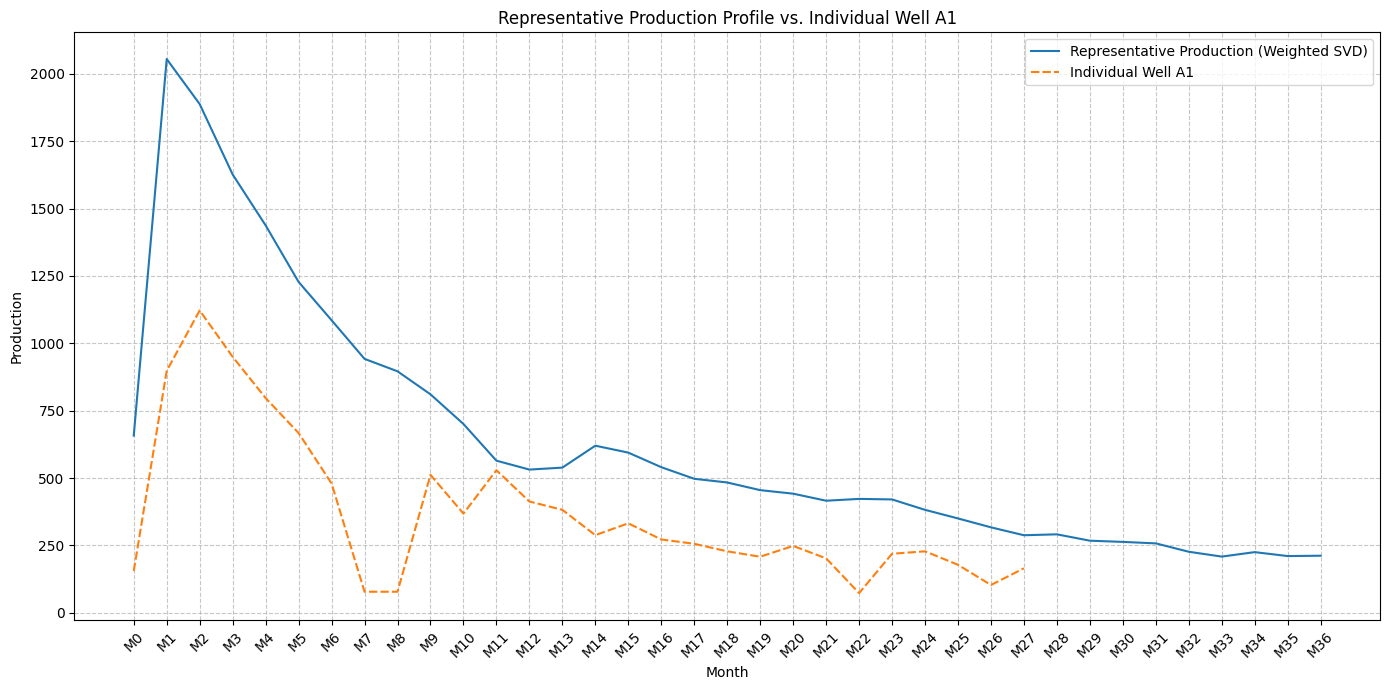

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select an individual well (e.g., WellID A1)
individual_well_id = 'A1'
individual_well_data = df[df['WellID'] == individual_well_id][production_cols].iloc[0]

# Convert to a DataFrame for plotting, aligning with representative_df structure
individual_well_df = pd.DataFrame(
    individual_well_data.values,
    index=production_cols,
    columns=[f'Individual Well {individual_well_id}']
)

# Combine the representative profile and the individual well's data for plotting
comparison_df = pd.concat([representative_df, individual_well_df], axis=1)

plt.figure(figsize=(14, 7))
sns.lineplot(data=comparison_df)
plt.title(f'Representative Production Profile vs. Individual Well {individual_well_id}')
plt.xlabel('Month')
plt.ylabel('Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot visually demonstrates how the representative profile (derived from weighted SVD) compares to the actual production of a specific well. It helps in assessing whether the representative profile captures the general decline trend of wells in the region, while also highlighting individual well variations.

### Visualizing All Individual Wells with the Representative Profile

This visualization will show all individual well production profiles (in light gray) along with the representative profile (in a contrasting color). This helps to see the variability among individual wells and how well the representative profile captures the overall trend.

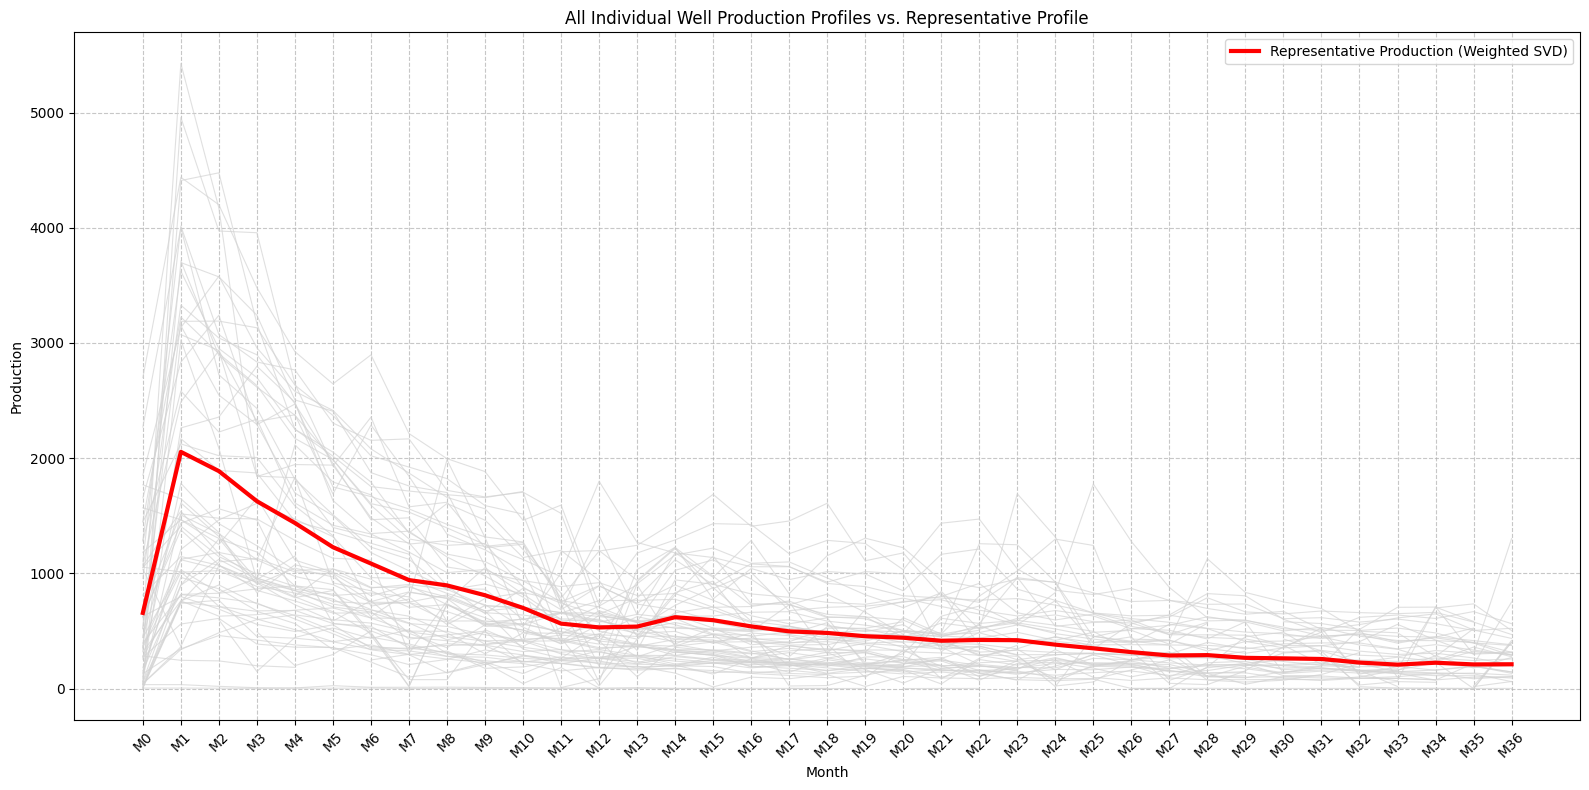

In [9]:
plt.figure(figsize=(16, 8))

# Plot all individual wells in a light grey color
for index, row in df.iterrows():
    plt.plot(production_cols, row[production_cols].values, color='lightgray', alpha=0.7, linewidth=0.8)

# Plot the representative profile with a distinct color and thicker line
plt.plot(
    representative_df.index,
    representative_df['Representative Production (Weighted SVD)'],
    color='red',
    linewidth=3,
    label='Representative Production (Weighted SVD)'
)

plt.title('All Individual Well Production Profiles vs. Representative Profile')
plt.xlabel('Month')
plt.ylabel('Production')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Fitting a Smooth Decline Curve to the Representative Profile

To further generalize the representative profile and allow for future forecasting, we can fit a mathematical decline curve model to it. A common choice for oil and gas wells is the exponential decline curve. We will use a function of the form `P(t) = A * exp(-B * t) + C`, where:

*   `P(t)` is the production at time `t`.
*   `A` is a coefficient related to initial production.
*   `B` is the decline rate.
*   `C` is the asymptotic production (often zero, but can be non-zero for certain decline patterns).

We will use `scipy.optimize.curve_fit` to find the optimal parameters `A`, `B`, and `C` for our `representative_df`.

Fitted Parameters: A=1552.10, B=0.0775, C=100.87


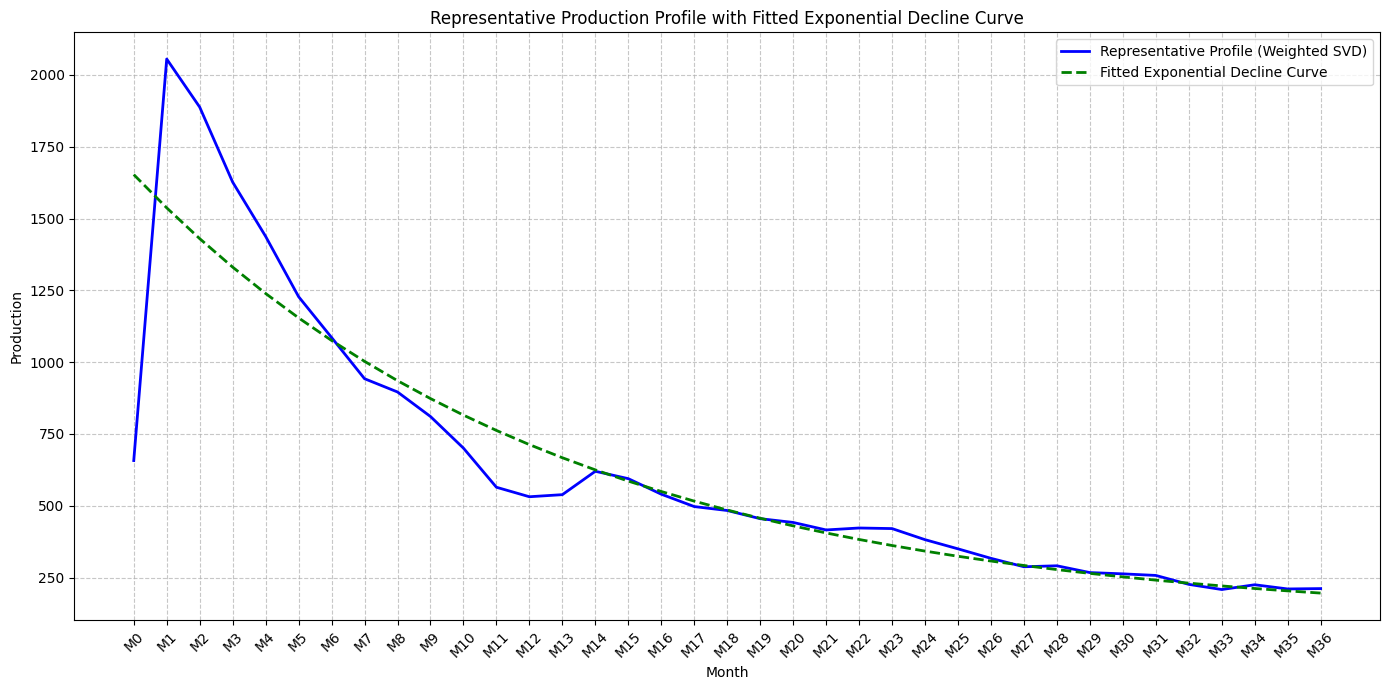

In [10]:
from scipy.optimize import curve_fit

# Define the exponential decline function
def exponential_decline(t, A, B, C):
    return A * np.exp(-B * t) + C

# Prepare data for fitting
x_data = np.arange(len(representative_df)) # Months as numerical values (0 to 36)
y_data = representative_df['Representative Production (Weighted SVD)'].values

# Initial guess for the parameters (A, B, C)
# A: close to initial production (y_data[0])
# B: a small positive decline rate (e.g., 0.1)
# C: close to the final production (y_data[-1]) or 0
initial_guess = [y_data[0], 0.1, y_data[-1]]

# Perform the curve fitting
try:
    params, covariance = curve_fit(exponential_decline, x_data, y_data, p0=initial_guess, maxfev=5000)
    A_fit, B_fit, C_fit = params

    # Generate the fitted curve using the optimized parameters
    fitted_curve_data = exponential_decline(x_data, A_fit, B_fit, C_fit)

    print(f"Fitted Parameters: A={A_fit:.2f}, B={B_fit:.4f}, C={C_fit:.2f}")

    # Plot the original representative profile and the fitted curve
    plt.figure(figsize=(14, 7))
    sns.lineplot(x=representative_df.index, y=y_data, label='Representative Profile (Weighted SVD)', color='blue', linewidth=2)
    sns.lineplot(x=representative_df.index, y=fitted_curve_data, label='Fitted Exponential Decline Curve', color='green', linestyle='--', linewidth=2)

    plt.title('Representative Production Profile with Fitted Exponential Decline Curve')
    plt.xlabel('Month')
    plt.ylabel('Production')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    print(f"Error fitting curve: {e}. Check initial guess or data.")

### Refining the Decline Curve Fit: Excluding M0 and Adjusting for Partial Month

As M0 often represents a partial production month and can distort the overall decline trend, we will refine the curve fitting process. We will:

1.  **Exclude M0 from the fitting**: Perform `curve_fit` using data from M1 onwards.
2.  **Estimate M0**: Once the curve is fitted, we will estimate the production for M0 as approximately half of the fitted M1 production, reflecting its nature as a partial month.
3.  **Plot the new fit**: Visualize this adjusted fitted curve against the original representative profile.

Refined Fitted Parameters (M1 onwards): A=2080.96, B=0.1474, C=268.14


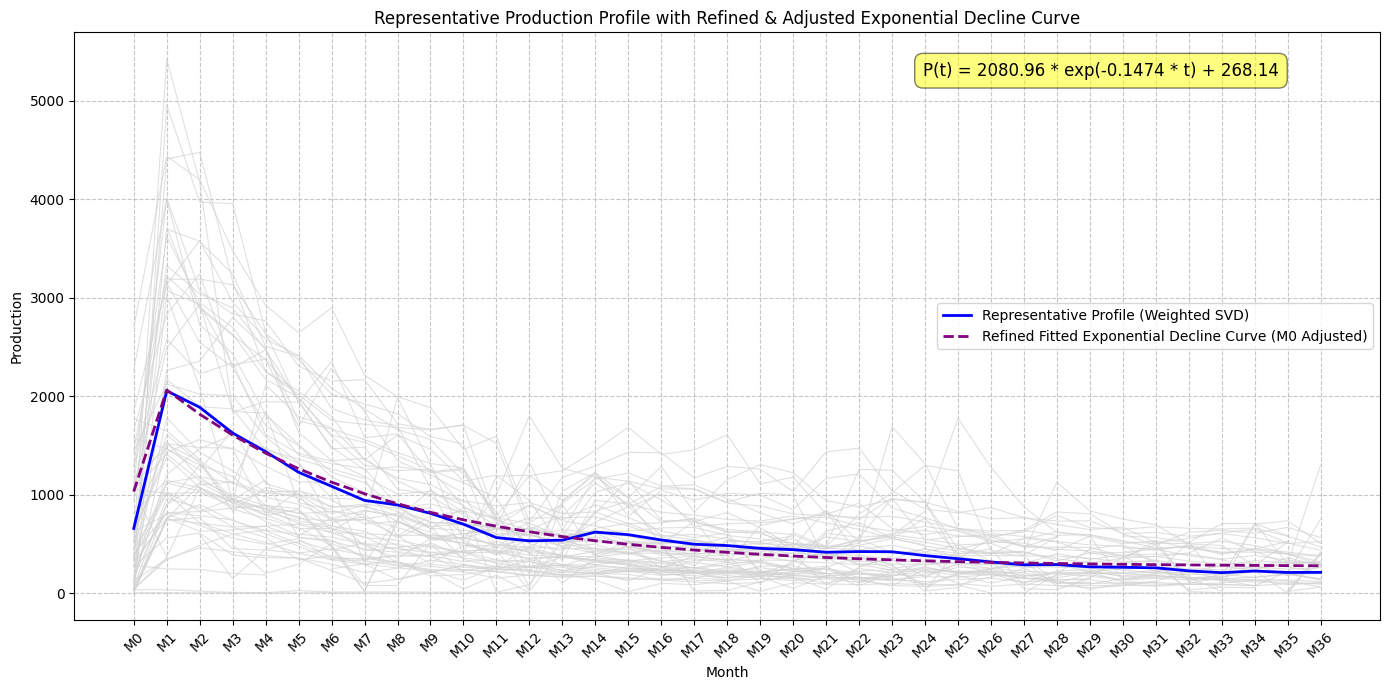

In [13]:
# Prepare data for fitting, excluding M0
x_data_refined = np.arange(1, len(representative_df)) # Months from 1 to 36
y_data_refined = representative_df['Representative Production (Weighted SVD)'].iloc[1:].values

# Initial guess for the parameters (A, B, C) for the refined data
# Use M1 production for A
initial_guess_refined = [y_data_refined[0], 0.1, y_data_refined[-1]]

# Perform the curve fitting on the refined data (M1 to M36)
try:
    params_refined, covariance_refined = curve_fit(exponential_decline, x_data_refined, y_data_refined, p0=initial_guess_refined, maxfev=5000)
    A_fit_refined, B_fit_refined, C_fit_refined = params_refined

    print(f"Refined Fitted Parameters (M1 onwards): A={A_fit_refined:.2f}, B={B_fit_refined:.4f}, C={C_fit_refined:.2f}")

    # Generate the fitted curve data for M1 to M36
    fitted_curve_data_refined = exponential_decline(x_data_refined, A_fit_refined, B_fit_refined, C_fit_refined)

    # Estimate M0 as approximately half of the fitted M1 production
    # The first element of fitted_curve_data_refined corresponds to M1 (x_data_refined[0])
    m0_estimated = fitted_curve_data_refined[0] / 2

    # Combine M0 estimated with the rest of the refined fitted data
    full_fitted_curve = np.insert(fitted_curve_data_refined, 0, m0_estimated)

    # Plot the original representative profile and the new, refined fitted curve
    plt.figure(figsize=(14, 7))

    # Plot all individual wells in a light grey color
    for index, row in df.iterrows():
        plt.plot(production_cols, row[production_cols].values, color='lightgray', alpha=0.7, linewidth=0.8)

    sns.lineplot(x=representative_df.index, y=representative_df['Representative Production (Weighted SVD)'], label='Representative Profile (Weighted SVD)', color='blue', linewidth=2)
    sns.lineplot(x=representative_df.index, y=full_fitted_curve, label='Refined Fitted Exponential Decline Curve (M0 Adjusted)', color='purple', linestyle='--', linewidth=2)

    plt.title('Representative Production Profile with Refined & Adjusted Exponential Decline Curve')
    plt.xlabel('Month')
    plt.ylabel('Production')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend()

    # Add equation and parameters to the plot
    equation_text = f"P(t) = {A_fit_refined:.2f} * exp(-{B_fit_refined:.4f} * t) + {C_fit_refined:.2f}"
    plt.text(0.65, 0.95, equation_text, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.tight_layout()
    plt.show()
except RuntimeError as e:
    print(f"Error fitting refined curve: {e}. Check initial guess or data.")